In [ ]:
!pip install upsetplot rapidfuzz

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import re
from difflib import SequenceMatcher
from pathlib import Path
from matplotlib.ticker import MaxNLocator
import numpy as np
from difflib import get_close_matches
BASE_DIR = Path("../Data")
QUARTILE_DIR = Path("../Quartile")

In [3]:
TOOL_ALIASES = {
    "googleacademico": "googlescholar",
    "googlescholar": "googlescholar",
    "google scholar": "googlescholar",
    "lens": "lens",
    "litmaps": "litmaps",
    "litmap": "litmaps",
    "researchrabbit": "researchrabbit",
    "semanticscholar": "semanticscholar",
    "semantic scholar": "semanticscholar",
    "openalex": "openalex",
    "opencitations": "opencitations",
    "snowmap": "snowmap",
    "nossatool": "snowmap",
    "our_tool": "snowmap",
    "our tool": "snowmap",
}


def normalize_title(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s or None

#finding columns
DOI_COL_CANDIDATES = [
    "doi", "DOI", "doi_norm", "document_doi", "paper_doi", "work_doi", "citing", "externalIds"
]

TITLE_COL_CANDIDATES = [
    "title", "Title", "paper_title", "document_title", "article_title",
    "display_name", "work_title", "titulo"
]


#normalization
def normalize_doi(x):
    if pd.isna(x):
        return None

    s = str(x).strip().lower()

    if s in {"", "nan", "none", "null", "x"}:
        return None

    s = s.replace("https://doi.org/", "")
    s = s.replace("http://doi.org/", "")
    s = s.replace("https://dx.doi.org/", "")
    s = s.replace("http://dx.doi.org/", "")
    s = s.replace("doi.org/", "")
    s = s.replace("doi:", "")
    s = s.strip()

    # cerca un DOI anche dentro stringhe più lunghe
    m = re.search(r"10\.\S+", s)
    if not m:
        return None

    s = m.group(0)
    s = s.rstrip(" .;,)")
    return s or None


def find_doi_column(df):
    cols_lower = {c.lower(): c for c in df.columns}

    for cand in DOI_COL_CANDIDATES:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    for c in df.columns:
        if "doi" in c.lower():
            return c

    return None


def find_title_column(df):
    cols_lower = {c.lower(): c for c in df.columns}

    for cand in TITLE_COL_CANDIDATES:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    for c in df.columns:
        if "title" in c.lower() or "titulo" in c.lower():
            return c

    return None


#read each csv
def read_csv_with_fallback(path):
    try:
        return pd.read_csv(path)
    except pd.errors.ParserError:
        try:
            return pd.read_csv(path, sep=";")
        except Exception:
            return None
    except UnicodeDecodeError:
        try:
            return pd.read_csv(path, encoding="latin1")
        except Exception:
            return None
    except Exception:
        return None


def prepare_normalized_df(csv_path: Path, verbose=True):
    df = read_csv_with_fallback(csv_path)
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    doi_col = find_doi_column(df)
    title_col = find_title_column(df)

    #warning
    if verbose:
        if doi_col is None:
            print(f"[WARNING] {csv_path.name} → colonna DOI NON trovata")
        if title_col is None:
            print(f"[WARNING] {csv_path.name} → colonna TITLE NON trovata")

    if doi_col is not None:
        df["doi_norm"] = df[doi_col].apply(normalize_doi)
    else:
        df["doi_norm"] = None

    if title_col is not None:
        df["title_norm"] = df[title_col].apply(normalize_title)
    else:
        df["title_norm"] = None

    return df, doi_col, title_col


SOURCE_COL_BY_TOOL = {
    "googlescholar": "Source",
    "lens": "Source Title",
    "litmaps": "Journal",
    "researchrabbit": "Journal",
    "openalex": "primary_location.source.display_name",
    "semanticscholar": "venue",
    "snowmap": "Venue",
    "opencitations": None,
}



#normalization venue
def normalize_tool_name(name: str) -> str:
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = name.replace(".csv", "")
    return name

def extract_tool_from_filename(fname: str) -> str:
    fname = fname.lower().strip()
    fname = re.sub(r"^artigo\d+_", "", fname)
    fname = fname.replace(".csv", "")
    return fname


def normalize_venue_name(name: str) -> str:
    if pd.isna(name):
        return None

    name = str(name).lower().strip()
    name = re.sub(r"[^a-z0-9 ]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()

    if not name:
        return None
    return name

from rapidfuzz import process

def find_best_fuzzy_match(venue, candidates, cutoff=88):
    if not venue:
        return None

    match = process.extractOne(venue, list(candidates))

    if match is None:
        return None

    best, score, _ = match

    return best if score >= cutoff else None


def get_quartile_with_match_type(venue, sjr_map, jcr_map, use_fuzzy=True, fuzzy_cutoff=88):
    v = normalize_venue_name(venue)

    if not v:
        return "No match", "no_match"

    if v in sjr_map:
        return sjr_map[v], "exact_sjr"

    if v in jcr_map:
        return jcr_map[v], "exact_jcr"

    if use_fuzzy:
        best_sjr = find_best_fuzzy_match(v, sjr_map.keys(), cutoff=fuzzy_cutoff)
        if best_sjr:
            return sjr_map[best_sjr], "fuzzy_sjr"

        best_jcr = find_best_fuzzy_match(v, jcr_map.keys(), cutoff=fuzzy_cutoff)
        if best_jcr:
            return jcr_map[best_jcr], "fuzzy_jcr"

    return "No match", "no_match"

from pathlib import Path

def extract_tool_from_filename(filename):
    stem = Path(filename).stem.lower().strip()

    # Snowmap aliases
    if "nossatool" in stem:
        return "snowmap"
    if "our_tool" in stem or "our tool" in stem:
        return "snowmap"
    if "snowmap" in stem:
        return "snowmap"

    # Remove "artigoXX_" prefix
    parts = stem.split("_", 1)
    if len(parts) > 1 and parts[0].startswith("artigo"):
        tool = parts[1]
    else:
        tool = stem

    # Normalize common aliases
    tool_aliases = {
        "googleacademico": "googlescholar",
        "google_scholar": "googlescholar",
        "google scholar": "googlescholar",
        "googlescholar": "googlescholar",
        "lens": "lens",
        "litmaps": "litmaps",
        "litmap": "litmaps",
        "researchrabbit": "researchrabbit",
        "research_rabbit": "researchrabbit",
        "semanticscholar": "semanticscholar",
        "semantic_scholar": "semanticscholar",
        "semantic scholar": "semanticscholar",
        "openalex": "openalex",
        "open_alex": "openalex",
        "opencitations": "opencitations",
        "open_citations": "opencitations",
        "nossatool": "snowmap",
        "our_tool": "snowmap",
        "snowmap": "snowmap",
    }

    return tool_aliases.get(tool, tool)



In [4]:
#load sjr and jcr
def load_sjr_jcr(sjr_path, jcr_path):
    sjr = read_csv_with_fallback(sjr_path)
    jcr = read_csv_with_fallback(jcr_path)

    if sjr is None or jcr is None:
        raise ValueError("Errore nel caricamento di SJR o JCR")

    sjr.columns = [c.lower().strip() for c in sjr.columns]
    jcr.columns = [c.lower().strip() for c in jcr.columns]

    return sjr, jcr

def normalize_journal_name(name):
    if is_missing_value(name):
        return None

    s = str(name).strip().lower()
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    if s in MISSING_TOKENS or not s:
        return None

    return s

#mapping match
def build_journal_maps(sjr, jcr):
    sjr_map = {}
    jcr_map = {}

    #sjr
    sjr_title_col = None
    sjr_quart_col = None

    for cand in ["title", "source title", "journal name"]:
        if cand in sjr.columns:
            sjr_title_col = cand
            break

    for cand in ["sjr best quartile", "sjr_best_quartile", "best quartile", "quartile"]:
        if cand in sjr.columns:
            sjr_quart_col = cand
            break

    if sjr_title_col and sjr_quart_col:
        for _, row in sjr.iterrows():
            name = normalize_venue_name(row.get(sjr_title_col))
            quartile = row.get(sjr_quart_col)

            if name and pd.notna(quartile):
                sjr_map[name] = str(quartile).strip()

    #jcr
    jcr_title_col = None
    jcr_quart_col = None

    for cand in ["journal name", "title", "source title"]:
        if cand in jcr.columns:
            jcr_title_col = cand
            break

    for cand in ["jif quartile", "quartile"]:
        if cand in jcr.columns:
            jcr_quart_col = cand
            break

    if jcr_title_col and jcr_quart_col:
        for _, row in jcr.iterrows():
            name = normalize_venue_name(row.get(jcr_title_col))
            quartile = row.get(jcr_quart_col)

            if name and pd.notna(quartile):
                jcr_map[name] = str(quartile).strip()

    return sjr_map, jcr_map

def find_journal_column(df):
    candidates = [
        "journal", "source", "venue",
        "publication", "source title"
    ]

    cols_lower = {c.lower(): c for c in df.columns}

    for cand in candidates:
        if cand in cols_lower:
            return cols_lower[cand]

    return None

def get_quartile(journal, sjr_map, jcr_map):
    j = normalize_journal_name(journal)

    if not j:
        return "No match"

    # priorità: SJR → JCR
    if j in sjr_map:
        return sjr_map[j]

    if j in jcr_map:
        return jcr_map[j]

    return "No match"

from collections import Counter

#match quartile
def get_quartile_with_match_type(venue, sjr_map, jcr_map, use_fuzzy=True, fuzzy_cutoff=0.92):
    v = normalize_venue_name(venue)

    if not v:
        return "No match", "no_match"

    if v in sjr_map:
        return sjr_map[v], "exact_sjr"

    if v in jcr_map:
        return jcr_map[v], "exact_jcr"

    if use_fuzzy:
        best_sjr = find_best_fuzzy_match(v, sjr_map.keys(), cutoff=fuzzy_cutoff)
        if best_sjr:
            return sjr_map[best_sjr], "fuzzy_sjr"

        best_jcr = find_best_fuzzy_match(v, jcr_map.keys(), cutoff=fuzzy_cutoff)
        if best_jcr:
            return jcr_map[best_jcr], "fuzzy_jcr"

    return "No match", "no_match"

#analysis file
def analyze_quartiles_in_file(csv_path, sjr_map, jcr_map, verbose=False):
    df = read_csv_with_fallback(csv_path)

    if df is None or df.empty:
        if verbose:
            print(f"[SKIP] File vuoto o non leggibile: {csv_path.name}")
        return None

    tool = normalize_tool_name(extract_tool_from_filename(csv_path.name))
    source_col = SOURCE_COL_BY_TOOL.get(tool)

    if source_col is None:
        if verbose:
            print(f"[SKIP] {csv_path.name}: nessuna colonna source definita per tool={tool}")
        return None

    if source_col not in df.columns:
        if verbose:
            print(f"[SKIP] {csv_path.name}: colonna '{source_col}' non trovata")
            print("Colonne disponibili:", list(df.columns))
        return None

    quartiles = []
    match_types = []
    no_match_original_venues = []

    for val in df[source_col]:
        q, mt = get_quartile_with_match_type(val, sjr_map, jcr_map, use_fuzzy=True, fuzzy_cutoff=0.92)
        quartiles.append(q)
        match_types.append(mt)
        if q == "-":
            no_match_original_venues.append(val)

    quartile_counter = Counter(quartiles)
    matchtype_counter = Counter(match_types)

    if verbose:
        print(f"\n[OK] {csv_path.name} | tool={tool}")
        print("Quartili:", dict(quartile_counter))
        print("Tipi di match:", dict(matchtype_counter))
        if no_match_original_venues:
            print("Original venues that returned '-':", no_match_original_venues)

    return {
        "quartiles": quartile_counter,
        "match_types": matchtype_counter,
        "no_match_venues": no_match_original_venues
    }


#analysis folder
def analyze_quartiles_in_folder(folder_path, sjr_map, jcr_map, verbose=False):
    results = {}

    for csv_path in Path(folder_path).glob("*.csv"):
        tool = normalize_tool_name(extract_tool_from_filename(csv_path.name))
        file_analysis_results = analyze_quartiles_in_file(csv_path, sjr_map, jcr_map, verbose=verbose)

        if file_analysis_results is not None:
            if tool not in results:
                results[tool] = {"quartiles": Counter(), "match_types": Counter(), "no_match_venues": []}
            results[tool]["quartiles"].update(file_analysis_results["quartiles"])
            results[tool]["match_types"].update(file_analysis_results["match_types"])
            results[tool]["no_match_venues"].extend(file_analysis_results["no_match_venues"])

    return results


#building the table
def build_quartile_table(results_dict):
    all_quartiles = ["Q1", "Q2", "Q3", "Q4", "No match"]

    if not results_dict:
        return pd.DataFrame(0, index=all_quartiles, columns=[])

    df = pd.DataFrame(0, index=all_quartiles, columns=sorted(results_dict.keys()))

    for tool, result in results_dict.items():
        if isinstance(result, dict) and "quartiles" in result:
            counter = result["quartiles"]
        else:
            counter = result

        for q, count in counter.items():
            q_clean = str(q).strip()

            if q_clean in df.index:
                df.loc[q_clean, tool] = count
            else:
                print(f"[WARN] quartile non riconosciuto: {q_clean} per tool={tool}")

    return df


#preparation for plot
def prepare_quartile_plot_df_from_table(quartile_df, slr_name):
    rows = []

    for quartile in quartile_df.index:
        for tool in quartile_df.columns:
            rows.append({
                "SLR": slr_name,
                "tool": tool,
                "quartile": quartile,
                "count": quartile_df.loc[quartile, tool]
            })

    return pd.DataFrame(rows)


def combine_quartile_plot_dfs(*dfs):
    valid = [df for df in dfs if df is not None and not df.empty]
    if not valid:
        return pd.DataFrame(columns=["SLR", "tool", "quartile", "count"])
    return pd.concat(valid, ignore_index=True)

In [ ]:
SJR_PATH = QUARTILE_DIR / "sjr_data.csv"
JCR_PATH = QUARTILE_DIR / "JCR_data.csv"


folder1 = Path("../Data/new_csvs_slr01")
folder2 = Path("../Data/new_csvs_slr02")
folder3 = Path("../Data/new_csvs_slr03")
folder4 = Path("../Data/new_csvs_slr04")


sjr, jcr = load_sjr_jcr(SJR_PATH, JCR_PATH)
sjr_map, jcr_map = build_journal_maps(sjr, jcr)

res1 = analyze_quartiles_in_folder(folder1, sjr_map, jcr_map, verbose=True)
q1 = build_quartile_table(res1)
plot_q1 = prepare_quartile_plot_df_from_table(q1, "SLR 1")

res2 = analyze_quartiles_in_folder(folder2, sjr_map, jcr_map, verbose=True)
q2 = build_quartile_table(res2)
plot_q2 = prepare_quartile_plot_df_from_table(q2, "SLR 2")

res3 = analyze_quartiles_in_folder(folder3, sjr_map, jcr_map, verbose=True)
q3 = build_quartile_table(res3)
plot_q3 = prepare_quartile_plot_df_from_table(q3, "SLR 3")

res4 = analyze_quartiles_in_folder(folder4, sjr_map, jcr_map, verbose=True)
q4 = build_quartile_table(res4)
plot_q4 = prepare_quartile_plot_df_from_table(q4, "SLR 4")

quartile_all_df = combine_quartile_plot_dfs(plot_q1, plot_q2, plot_q3, plot_q4)

display(q1)
display(plot_q1)
display(quartile_all_df)

[SKIP] g-t_artigo01.csv: nessuna colonna source definita per tool=g-t_artigo01

[OK] artigo01_openAlex.csv | tool=openalex
Quartili: {'Q1': 12, 'No match': 6, 'Q2': 1}
Tipi di match: {'fuzzy_sjr': 9, 'no_match': 6, 'exact_sjr': 4}

[OK] artigo01_googleScholar.csv | tool=googlescholar
Quartili: {'-': 35, 'Q1': 59, 'Q4': 2, 'No match': 33, 'Q3': 3, 'Q2': 3}
Tipi di match: {'fuzzy_sjr': 94, 'no_match': 33, 'exact_sjr': 8}
Original venues that returned '-': ['arXiv preprint arXiv:2602.17697', 'arXiv preprint arXiv …', 'Proceedings of the 29th …', 'arXiv preprint arXiv:2407.02706', 'arXiv preprint arXiv:2310.02658', 'Proceedings of the 29th …', 'International Conference on …', 'Proceedings of the 29th …', 'Proceedings of the ACM …', 'Proceedings of the 19th …', 'arXiv preprint arXiv …', 'arXiv preprint arXiv …', 'Proceedings of the 29th …', 'arXiv preprint arXiv …', 'International Conference on …', 'Proceedings of the 27th …', 'Proceedings of the 28th …', 'Proceedings of the 26th …', 'arXiv

,googlescholar,lens,litmaps,openalex,researchrabbit,semanticscholar,snowmap
Q1,59,75,98,12,98,44,93
Q2,3,2,21,1,21,7,9
Q3,3,0,4,0,4,5,5
Q4,2,1,11,0,11,7,9
No match,33,3,0,6,0,26,1


,SLR,tool,quartile,count
0,SLR 1,googlescholar,Q1,59
1,SLR 1,lens,Q1,75
2,SLR 1,litmaps,Q1,98
3,SLR 1,openalex,Q1,12
4,SLR 1,researchrabbit,Q1,98
5,SLR 1,semanticscholar,Q1,44
6,SLR 1,snowmap,Q1,93
7,SLR 1,googlescholar,Q2,3
8,SLR 1,lens,Q2,2
9,SLR 1,litmaps,Q2,21


,SLR,tool,quartile,count
0,SLR 1,googlescholar,Q1,59
1,SLR 1,lens,Q1,75
2,SLR 1,litmaps,Q1,98
3,SLR 1,openalex,Q1,12
4,SLR 1,researchrabbit,Q1,98
...,...,...,...,...
135,SLR 4,litmaps,No match,0
136,SLR 4,openalex,No match,8
137,SLR 4,researchrabbit,No match,0
138,SLR 4,semanticscholar,No match,0


In [6]:
display(q1)
display(q2)
display(q3)
display(q4)

,googlescholar,lens,litmaps,openalex,researchrabbit,semanticscholar,snowmap
Q1,59,75,98,12,98,44,93
Q2,3,2,21,1,21,7,9
Q3,3,0,4,0,4,5,5
Q4,2,1,11,0,11,7,9
No match,33,3,0,6,0,26,1


,googlescholar,lens,litmaps,openalex,researchrabbit,semanticscholar,snowmap
Q1,33,5,22,15,22,19,22
Q2,10,5,11,8,10,8,10
Q3,1,0,1,0,1,1,1
Q4,0,2,2,1,2,1,3
No match,7,0,0,4,0,4,1


,googlescholar,lens,litmaps,openalex,researchrabbit,semanticscholar,snowmap
Q1,304,44,260,229,251,231,247
Q2,70,4,76,58,69,56,59
Q3,32,0,25,20,25,24,24
Q4,9,3,18,12,16,15,17
No match,129,2,0,42,0,5,1


,googlescholar,lens,litmaps,openalex,researchrabbit,semanticscholar,snowmap
Q1,13,4,6,1,6,4,5
Q2,4,2,1,0,1,1,2
Q3,0,0,0,0,0,0,0
Q4,0,2,3,3,3,2,3
No match,3,0,0,8,0,0,0


In [7]:
#q1 = q1.T
#q2 = q2.T
#q3 = q3.T
#q4 = q4.T

quartile_order = ["Q1", "Q2", "Q3", "Q4", "No match"]
tool_order = [
    "googlescholar",
    "lens",
    "litmaps",
    "openalex",
    "researchrabbit",
    "semanticscholar",
    "snowmap"
]

q1 = q1.reindex(index=quartile_order, columns=tool_order, fill_value=0)
q2 = q2.reindex(index=quartile_order, columns=tool_order, fill_value=0)
q3 = q3.reindex(index=quartile_order, columns=tool_order, fill_value=0)
q4 = q4.reindex(index=quartile_order, columns=tool_order, fill_value=0)

In [ ]:


def plot_quartile_percent_2x2(q1, q2, q3, q4, out_file=None):
    quartile_order = ["Q1", "Q2", "Q3", "Q4", "No match"]

    slr_tables = {
        "SLR 1": q1.copy(),
        "SLR 2": q2.copy(),
        "SLR 3": q3.copy(),
        "SLR 4": q4.copy(),
    }

    tool_order = [
        "googlescholar",
        "lens",
        "litmaps",
        "openalex",
        "researchrabbit",
        "semanticscholar",
        "snowmap"
    ]

    colors = {
        "Q1": "tab:blue",
        "Q2": "tab:orange",
        "Q3": "tab:green",
        "Q4": "tab:red",
        "No match": "lightgray"
    }

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True)
    axes = axes.flatten()

    legend_handles = []
    legend_labels = quartile_order

    for idx, (ax, (slr_name, df)) in enumerate(zip(axes, slr_tables.items())):
        df = df.copy()

        df.index = [str(i).strip() for i in df.index]
        df.columns = [str(c).strip().lower() for c in df.columns]

        present_tools = [t for t in tool_order if t in df.columns]
        df = df.reindex(index=quartile_order, columns=present_tools, fill_value=0)

        col_sums = df.sum(axis=0).replace(0, np.nan)
        df_pct = df.div(col_sums, axis=1) * 100
        df_pct = df_pct.fillna(0)

        bottoms = np.zeros(len(df_pct.columns))

        for q in quartile_order:
            bars = ax.bar(
                df_pct.columns,
                df_pct.loc[q].values,
                bottom=bottoms,
                color=colors[q],
                edgecolor="white",
                linewidth=0.5,
                label=q
            )
            bottoms += df_pct.loc[q].values

            if idx == 0:
                legend_handles.append(bars[0])

        ax.set_title(slr_name, fontsize=14, fontweight="bold")
        ax.set_ylabel("% of citations")
        ax.set_ylim(0, 100)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        ax.tick_params(axis="x", rotation=30)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    fig.legend(
        legend_handles,
        legend_labels,
        title="Tool",
        loc="upper center",
        ncol=6,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])


    plt.show()

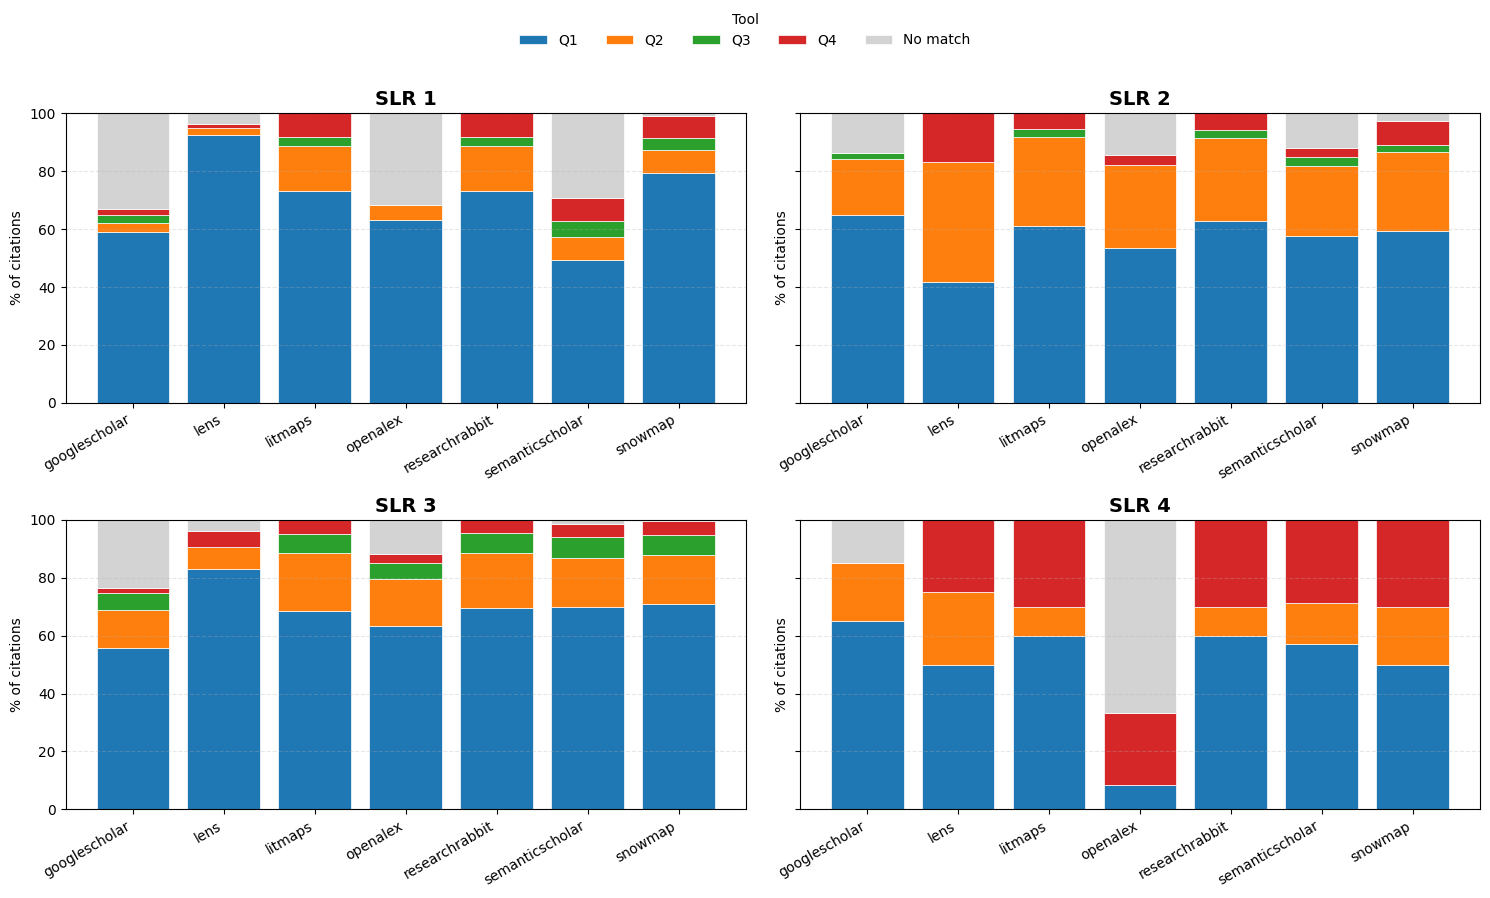

In [9]:
plot_quartile_percent_2x2(q1, q2, q3, q4, out_file="quartile_2x2_percent.png")